In [ ]:
#Autres modules importants à utiliser
import numpy as np
import scipy.stats as stats
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from typing import Dict, List, Tuple, Any, Optional
import os
import sys
import pickle
import time
from skimage.restoration import denoise_tv_chambolle

In [ ]:
module_path = os.path.abspath(os.path.join('..', 'src'))
if module_path not in sys.path:
    sys.path.insert(0, module_path)

from jgs_utils import *
from jgs_estimator import *

In [ ]:
def sensitivity_analysis_k(graphon_id: int, vec_n: List[int], 
                          graphon_size: int = 1000, 
                          REP: int = 100,
                          k_factor_range: Tuple[float, float] = (0.2, 3.0),
                          k_points: int = 20,
                          k_theo_method: str = "balanced",
                          include_theoretical: bool = True,
                          compute_gw: bool = False) -> Dict[str, Any]:
    """
    Complete sensitivity analysis of parameter k with true optimum.
    
    Args:
        k_factor_range: Tuple (min_factor, max_factor) for k range around k_theo
        k_points: Number of k points to test
        k_theo_method: Method to compute k_theo ('balanced', 'empty_blocks', 'minimax')
        compute_gw: If True, computes Gromov-Wasserstein distance (may be slow)
    """
    
    # True graphon
    true_graphon = generate_true_graphon_matrix(graphon_size, graphon_id)
    
    # Calculation of theoretical k values
    theoretical_vals = theoretical_k_choice(len(vec_n), vec_n, method=k_theo_method)
    k_theo = theoretical_vals.get('k_theoretical', theoretical_vals['k_balanced'])
    
    print("=== Theoretical k values ===")
    for key, val in theoretical_vals.items():
        if val is not None and 'k_' in key:
            print(f"{key}: {val:.2f}")
    
    # Generation of k_range around k_theo
    k_min = max(2, int(k_factor_range[0] * k_theo))
    k_max = min(100, int(k_factor_range[1] * k_theo))
    
    k_range_float = np.linspace(k_min, k_max, k_points)
    k_range = [int(round(k)) for k in k_range_float]
    k_range = sorted(set(k_range))  # Remove duplicates
    
    print(f"\nTested k range: {k_range[0]} to {k_range[-1]} (around k_theo = {k_theo:.1f})")
    print(f"Factors: {k_factor_range[0]:.1f} to {k_factor_range[1]:.1f} × k_theo")
    if compute_gw:
        print("GW distance calculation: ENABLED (may be slow)")
    else:
        print("GW distance calculation: DISABLED")
    
    # Storage of detailed results
    all_errors = []
    results = []
    
    for repetition in range(REP):
        print(f"Repetition: {repetition+1}/{REP}")
        
        # Graph generation
        graph_data = generate_graphs_from_graphon(vec_n, graphon_id)
        graphs = graph_data["graphs"]
        
        row_data = {"repetition": repetition}
        repetition_errors = {}
        
        for k in k_range:
            try:
                # Estimation with current k
                estim = joint_graph_sorting_estimate(graphs, k=k, smoothing=True)

                #estim_graphon_resized=estim["edge_frequencies"]
                # Post-processing
                estim_graphon_resized = interpolate_graphon(estim["edge_frequencies"], graphon_size)
                np.fill_diagonal(estim_graphon_resized, 0.0)
                
                # Calculation of basic error metrics (L2)
                l2_error = graphon_L2_norm(estim_graphon_resized, true_graphon)
                
                row_data[f"k_{k}_l2"] = l2_error
                row_data[f"k_{k}_success"] = True
                row_data[f"k_{k}_factor"] = k / k_theo
                
                # Optional GW distance calculation
                if compute_gw:
                    try:
                        gw_error = gw_distance(estim_graphon_resized, true_graphon)
                        row_data[f"k_{k}_gw"] = gw_error
                    except Exception as gw_e:
                        print(f"  GW distance failed for k={k}: {gw_e}")
                        row_data[f"k_{k}_gw"] = np.nan
                else:
                    row_data[f"k_{k}_gw"] = np.nan
                
                repetition_errors[k] = l2_error
                
            except Exception as e:
                print(f"Error with k={k}: {e}")
                row_data[f"k_{k}_l2"] = np.nan
                row_data[f"k_{k}_gw"] = np.nan
                row_data[f"k_{k}_success"] = False
                row_data[f"k_{k}_factor"] = np.nan
                repetition_errors[k] = np.nan
        
        results.append(row_data)
        all_errors.append(repetition_errors)
    
    # Conversion to DataFrame
    df_results = pd.DataFrame(results)
    
    # Calculation of aggregate statistics for L2
    l2_columns = [col for col in df_results.columns if col.endswith('_l2')]
    mean_errors = df_results[l2_columns].mean()
    std_errors = df_results[l2_columns].std()
    
    # Find the GLOBAL empirical optimal k (based on L2)
    optimal_k_idx = mean_errors.idxmin()
    optimal_k_global = int(optimal_k_idx.split('_')[1])
    optimal_error_global = mean_errors[optimal_k_idx]
    optimal_factor_global = optimal_k_global / k_theo
    
    # Find the optimal k for EACH repetition
    optimal_k_per_rep = []
    optimal_factor_per_rep = []
    for rep_errors in all_errors:
        valid_errors = {k: err for k, err in rep_errors.items() if not np.isnan(err)}
        if valid_errors:
            best_k = min(valid_errors, key=valid_errors.get)
            optimal_k_per_rep.append(best_k)
            optimal_factor_per_rep.append(best_k / k_theo)
    
    optimal_k_distribution = pd.Series(optimal_k_per_rep)
    optimal_factor_distribution = pd.Series(optimal_factor_per_rep)
    
    print(f"\n=== Sensitivity analysis results ===")
    print(f"Theoretical reference k: {k_theo:.1f}")
    print(f"Global optimal k (L2): {optimal_k_global} (factor: {optimal_factor_global:.2f} × k_theo)")
    print(f"Optimal L2 error: {optimal_error_global:.4f}")
    print(f"\nDistribution of optimal k per repetition:")
    print(f"  Mean = {optimal_k_distribution.mean():.1f} (factor: {optimal_factor_distribution.mean():.2f} × k_theo)")
    print(f"  Median = {optimal_k_distribution.median():.1f}")
    print(f"  Std = {optimal_k_distribution.std():.2f}")
    
    # Statistics for GW if calculated
    if compute_gw:
        gw_columns = [col for col in df_results.columns if col.endswith('_gw')]
        gw_mean_errors = df_results[gw_columns].mean()
        if not gw_mean_errors.isna().all():
            optimal_k_gw_idx = gw_mean_errors.idxmin()
            optimal_k_gw = int(optimal_k_gw_idx.split('_')[1])
            optimal_gw_error = gw_mean_errors[optimal_k_gw_idx]
            print(f"Global optimal k (GW): {optimal_k_gw} (factor: {optimal_k_gw/k_theo:.2f} × k_theo)")
            print(f"Optimal GW error: {optimal_gw_error:.4f}")
    
    return {
        'df_results': df_results,
        'optimal_k_global': optimal_k_global,
        'optimal_error_global': optimal_error_global,
        'optimal_factor_global': optimal_factor_global,
        'optimal_k_distribution': optimal_k_distribution,
        'optimal_factor_distribution': optimal_factor_distribution,
        'k_theo': k_theo,
        'theoretical_vals': theoretical_vals,
        'all_errors': all_errors,
        'k_range': k_range,
        'compute_gw': compute_gw
    }

In [ ]:
def theoretical_k_choice(M: int, n_list: List[int], method: str = "balanced") -> Dict[str, float]:
    """
    Calcule les valeurs théoriques de k selon différentes approches.
    
    Args:
        M: Nombre de graphes
        n_list: Liste des tailles des graphes
        method: Méthode de calcul ('balanced', 'minimax', 'empty_blocks')
    
    Returns:
        Dict avec les différentes valeurs théoriques de k
    """
    N = sum(n_list)  # Nombre total de nœuds
    S = sum(n**2 for n in n_list)  # Nombre total de paires possibles
    
    # k optimal par équilibrage biais-variance
    k_select = S**0.25
    
    # k pour éviter les blocs vides (condition suffisante)
    c = 3.0  # constante empirique
    k_empty_blocks = N / (c * (M + np.log(N)))

    k_balanced=int(np.min([k_empty_blocks,k_select]))
    
    # k classique pour un seul graphe (référence)
    if M == 1 and len(n_list) == 1:
        k_classical = np.sqrt(n_list[0])
    else:
        k_classical = None
    
    theoretical_values = {
        'k_balanced': k_balanced,
        'k_empty_blocks': k_empty_blocks,
        'k_classical': k_classical,
        'S': S,
        'N': N
    }
    
    # Choix selon la méthode spécifiée
    if method == "balanced":
        theoretical_values['k_theoretical'] = k_balanced
    elif method == "empty_blocks":
        theoretical_values['k_theoretical'] = k_empty_blocks
    elif method == "minimax":
        # Approximation du taux minimax pour multiple graphes
        k_theoretical = (S / np.log(N))**0.25 if N > 1 else k_balanced
        theoretical_values['k_theoretical'] = k_theoretical
    
    return theoretical_values

In [ ]:
def load_and_plot_all_graphons(results_dir: str = 'SensitivityResults',
                              metric: str = 'l2',
                              filename: str = 'all_graphons_sensitivity.png',
                              figsize: Tuple[int, int] = (15, 10),
                              legend_fontsize: int = 18,
                              k_theo=None,
                              log_scale: bool = True):
    """
    Loads and plots sensitivity results for the 12 graphons.
    k_theoretical is the same for all (same vec_n).
    """
    
    print(f"Searching in directory: {results_dir}")
    
    if not os.path.exists(results_dir):
        print(f"ERROR: Directory {results_dir} does not exist!")
        return None, None
    
    file_pattern = re.compile(r'results_graphon_(\d+)_k_analysis\.csv')
    colors = plt.cm.tab20(np.linspace(0, 1, 12))
    
    plt.figure(figsize=figsize)
    
    all_data = {}
    k_theo_global = k_theo  # Use the provided parameter value
    
    # If k_theo is not provided, try to find it in the files
    if k_theo_global is None:
        for file in os.listdir(results_dir):
            match = file_pattern.match(file)
            if match:
                filepath = os.path.join(results_dir, file)
                try:
                    df = pd.read_csv(filepath)
                    if 'k_theo' in df.columns:
                        k_theo_global = df['k_theo'].dropna().iloc[0] if not df['k_theo'].isna().all() else None
                        if k_theo_global is not None:
                            print(f"Global k_theoretical found: {k_theo_global}")
                            break
                except Exception as e:
                    print(f"Error reading k_theo: {e}")
                    continue
    
    # Second pass: collect all data
    for file in os.listdir(results_dir):
        match = file_pattern.match(file)
        if match:
            graphon_id = int(match.group(1))
            filepath = os.path.join(results_dir, file)
            
            try:
                df = pd.read_csv(filepath)
                
                # Extract metric data
                k_values = []
                metric_values = []
                
                for col in df.columns:
                    if col.startswith('k_') and col.endswith(f'_{metric}'):
                        k = int(col.split('_')[1])
                        k_values.append(k)
                        metric_values.append(df[col].mean())
                
                if k_values and metric_values:
                    sorted_indices = np.argsort(k_values)
                    k_values = [k_values[i] for i in sorted_indices]
                    metric_values = [metric_values[i] for i in sorted_indices]
                    
                    # Find empirical k_optimal
                    optimal_idx = np.argmin(metric_values)
                    optimal_k = k_values[optimal_idx]
                    optimal_value = metric_values[optimal_idx]
                    
                    all_data[graphon_id] = {
                        'k_values': k_values,
                        'metric_values': metric_values,
                        'color': colors[graphon_id - 1],
                        'optimal_k': optimal_k,
                        'optimal_value': optimal_value
                    }
                    
            except Exception as e:
                print(f"Error with {filepath}: {e}")
    
    if not all_data:
        print("No valid data found!")
        return None, k_theo_global
    
    # Sort by graphon ID
    sorted_graphon_ids = sorted(all_data.keys())
    
    # Plot all curves
    for graphon_id in sorted_graphon_ids:
        data = all_data[graphon_id]
        plt.plot(data['k_values'], data['metric_values'], 
                'o-', linewidth=2, markersize=4,
                color=data['color'], 
                label=f'Graphon {graphon_id+1}',
                alpha=0.8)
        
        # Mark empirical k_optimal
        plt.plot(data['optimal_k'], data['optimal_value'], 's', 
                markersize=8, color=data['color'], 
                markeredgecolor='black', markeredgewidth=1)
    
    # Mark GLOBAL k_theoretical if available
    if k_theo_global is not None:
        plt.axvline(x=k_theo_global, color='red', linestyle='--', 
                   linewidth=2, alpha=0.7, label=f'k_theoretical = {k_theo_global:.1f}')
        
        # Find y range for label
        all_errors = [val for data in all_data.values() for val in data['metric_values']]
        if all_errors:
            y_min, y_max = min(all_errors), max(all_errors)
            
            if log_scale:
                # For log scale, use relative position
                y_label = 10**(np.log10(y_min) + 0.1 * (np.log10(y_max) - np.log10(y_min)))
            else:
                y_label = y_min + 0.1 * (y_max - y_min)
            
            plt.text(k_theo_global, y_label, f'k_theoretical\n{k_theo_global:.1f}', 
                    ha='center', va='bottom', fontsize=11, color='red',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    plt.xlabel('Number of blocks k', fontsize=16)
    #plt.ylabel(f'{metric}', fontsize=16)
    plt.ylabel('MISE', fontsize=16)
    
    # Apply logarithmic scale if requested
    if log_scale:
        plt.yscale('log')
    
    # Title that handles the case where k_theo_global is None
    #title = f'Sensitivity Analysis: {metric} vs k for All Graphons'
   # if log_scale:
   #     title += ' (log scale)'
  #  if k_theo_global is not None:
 #       title += f'\n(k_theoretical = {k_theo_global:.1f})'
    
    #plt.title(title, fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=legend_fontsize)
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    # COMPARISON TABLE (only if k_theo_global is available)
    if k_theo_global is not None:
        print("\n" + "="*70)
        print("COMPARISON: empirical k_optimal vs k_theoretical (same for all)")
        print("="*70)
        print(f"Common k_theoretical: {k_theo_global:.1f}")
        print("-"*70)
        print(f"{'Graphon':<8} {'k_optimal':<12} {'Difference':<15} {'Ratio':<10} {'L2 Error':<12}")
        print("-"*70)
        
        optimal_ks = []
        ratios = []
        
        for graphon_id in sorted_graphon_ids:
            data = all_data[graphon_id]
            k_optimal = data['optimal_k']
            difference = k_optimal - k_theo_global
            ratio = k_optimal / k_theo_global
            
            optimal_ks.append(k_optimal)
            ratios.append(ratio)
            
            print(f"{graphon_id:<8} {k_optimal:<12} {difference:<15.1f} {ratio:<10.2f} {data['optimal_value']:<12.4f}")
        
        # Statistics
        print("-"*70)
        print(f"{'Mean':<8} {np.mean(optimal_ks):<12.1f} {np.mean([k - k_theo_global for k in optimal_ks]):<15.1f} "
              f"{np.mean(ratios):<10.2f} -")
        print(f"{'Std':<8} {np.std(optimal_ks):<12.1f} -{'':<14} {np.std(ratios):<10.2f} -")
    else:
        print("\nNo k_theoretical found - displaying k_optimal only:")
        for graphon_id in sorted_graphon_ids:
            data = all_data[graphon_id]
            print(f"Graphon {graphon_id}: k_optimal = {data['optimal_k']}, error = {data['optimal_value']:.4f}")
    
    return all_data, k_theo_global

In [ ]:
vec_n = np.random.randint(10, 100, size=100)

In [7]:

# Create the folder if it does not exist
os.makedirs('SensitivityResults', exist_ok=True)

In [8]:
results_L2_0 = sensitivity_analysis_k(
    graphon_id=0, 
    vec_n=vec_n,
    compute_gw=False,
    REP=100  
)
results_L2_0['df_results'].to_csv(f'SensitivityResults/results_graphon_{0}_k_analysis.csv', index=False)

=== Theoretical k values ===
k_balanced: 16.00
k_empty_blocks: 16.87
k_theoretical: 16.00

Tested k range: 3 to 48 (around k_theo = 16.0)
Factors: 0.2 to 3.0 × k_theo
GW distance calculation: DISABLED
Repetition: 1/100
Repetition: 2/100
Repetition: 3/100
Repetition: 4/100
Repetition: 5/100
Repetition: 6/100
Repetition: 7/100
Repetition: 8/100
Repetition: 9/100
Repetition: 10/100
Repetition: 11/100
Repetition: 12/100
Repetition: 13/100
Repetition: 14/100
Repetition: 15/100
Repetition: 16/100
Repetition: 17/100
Repetition: 18/100
Repetition: 19/100
Repetition: 20/100
Repetition: 21/100
Repetition: 22/100
Repetition: 23/100
Repetition: 24/100
Repetition: 25/100
Repetition: 26/100
Repetition: 27/100
Repetition: 28/100
Repetition: 29/100
Repetition: 30/100
Repetition: 31/100
Repetition: 32/100
Repetition: 33/100
Repetition: 34/100
Repetition: 35/100
Repetition: 36/100
Repetition: 37/100


KeyboardInterrupt: 

In [ ]:
results_L2_1 = sensitivity_analysis_k(
    graphon_id=1,graphon_size=1000, 
    vec_n=vec_n,
    compute_gw=False,
    REP=100  
)
results_L2_1['df_results'].to_csv(f'SensitivityResults/results_graphon_{1}_k_analysis.csv', index=False)

In [ ]:
results_L2_2 = sensitivity_analysis_k(
    graphon_id=2, 
    vec_n=vec_n,
    compute_gw=False,
    REP=100 
)

results_L2_2['df_results'].to_csv(f'SensitivityResults/results_graphon_{2}_k_analysis.csv', index=False)

In [ ]:
results_L2_3 = sensitivity_analysis_k(
    graphon_id=3, 
    vec_n=vec_n,
    compute_gw=False,
    REP=100 
)
results_L2_3['df_results'].to_csv(f'SensitivityResults/results_graphon_{3}_k_analysis.csv', index=False)

In [ ]:
results_L2_4 = sensitivity_analysis_k(
    graphon_id=4, 
    vec_n=vec_n,
    compute_gw=False,
    REP=100 
)
results_L2_4['df_results'].to_csv(f'SensitivityResults/results_graphon_{4}_k_analysis.csv', index=False)

In [ ]:
results_L2_5 = sensitivity_analysis_k(
    graphon_id=5, 
    vec_n=vec_n,
    compute_gw=False,
    REP=100 
)
results_L2_5['df_results'].to_csv(f'SensitivityResults/results_graphon_{5}_k_analysis.csv', index=False)

In [ ]:
results_L2_6 = sensitivity_analysis_k(
    graphon_id=6, 
    vec_n=vec_n,
    compute_gw=False,
    REP=100  
)
results_L2_6['df_results'].to_csv(f'SensitivityResults/results_graphon_{6}_k_analysis.csv', index=False)

In [ ]:
results_L2_7 = sensitivity_analysis_k(
    graphon_id=7, 
    vec_n=vec_n,
    compute_gw=False,
    REP=100  
)
results_L2_7['df_results'].to_csv(f'SensitivityResults/results_graphon_{7}_k_analysis.csv', index=False)

In [ ]:
results_L2_8 = sensitivity_analysis_k(
    graphon_id=8, 
    vec_n=vec_n,
    compute_gw=False,
    REP=100  
)
results_L2_8['df_results'].to_csv(f'SensitivityResults/results_graphon_{8}_k_analysis.csv', index=False)

In [ ]:
results_L2_9 = sensitivity_analysis_k(
    graphon_id=9, 
    vec_n=vec_n,
    compute_gw=False,
    REP=100  
)
results_L2_9['df_results'].to_csv(f'SensitivityResults/results_graphon_{9}_k_analysis.csv', index=False)

In [ ]:
results_L2_10 = sensitivity_analysis_k(
    graphon_id=10, 
    vec_n=vec_n,
    compute_gw=False,
    REP=100  
)
results_L2_10['df_results'].to_csv(f'SensitivityResults/results_graphon_{10}_k_analysis.csv', index=False)

In [ ]:
results_L2_11 = sensitivity_analysis_k(
    graphon_id=11, 
    vec_n=vec_n,
    compute_gw=False,
    REP=100  
)

results_L2_11['df_results'].to_csv(f'SensitivityResults/results_graphon_{11}_k_analysis.csv', index=False)

In [9]:
results_L2_11 = sensitivity_analysis_k(
    graphon_id=12, 
    vec_n=vec_n,
    compute_gw=False,
    REP=100  
)

results_L2_12['df_results'].to_csv(f'SensitivityResults/results_graphon_{12}_k_analysis.csv', index=False)

=== Theoretical k values ===
k_balanced: 16.00
k_empty_blocks: 16.87
k_theoretical: 16.00

Tested k range: 3 to 48 (around k_theo = 16.0)
Factors: 0.2 to 3.0 × k_theo
GW distance calculation: DISABLED
Repetition: 1/100
Repetition: 2/100
Repetition: 3/100
Repetition: 4/100
Repetition: 5/100
Repetition: 6/100
Repetition: 7/100
Repetition: 8/100
Repetition: 9/100
Repetition: 10/100
Repetition: 11/100
Repetition: 12/100
Repetition: 13/100
Repetition: 14/100
Repetition: 15/100
Repetition: 16/100
Repetition: 17/100
Repetition: 18/100
Repetition: 19/100
Repetition: 20/100
Repetition: 21/100
Repetition: 22/100
Repetition: 23/100
Repetition: 24/100
Repetition: 25/100
Repetition: 26/100
Repetition: 27/100
Repetition: 28/100
Repetition: 29/100
Repetition: 30/100
Repetition: 31/100
Repetition: 32/100
Repetition: 33/100
Repetition: 34/100
Repetition: 35/100
Repetition: 36/100
Repetition: 37/100
Repetition: 38/100
Repetition: 39/100
Repetition: 40/100
Repetition: 41/100
Repetition: 42/100
Repetition

Searching in directory: SensitivityResults


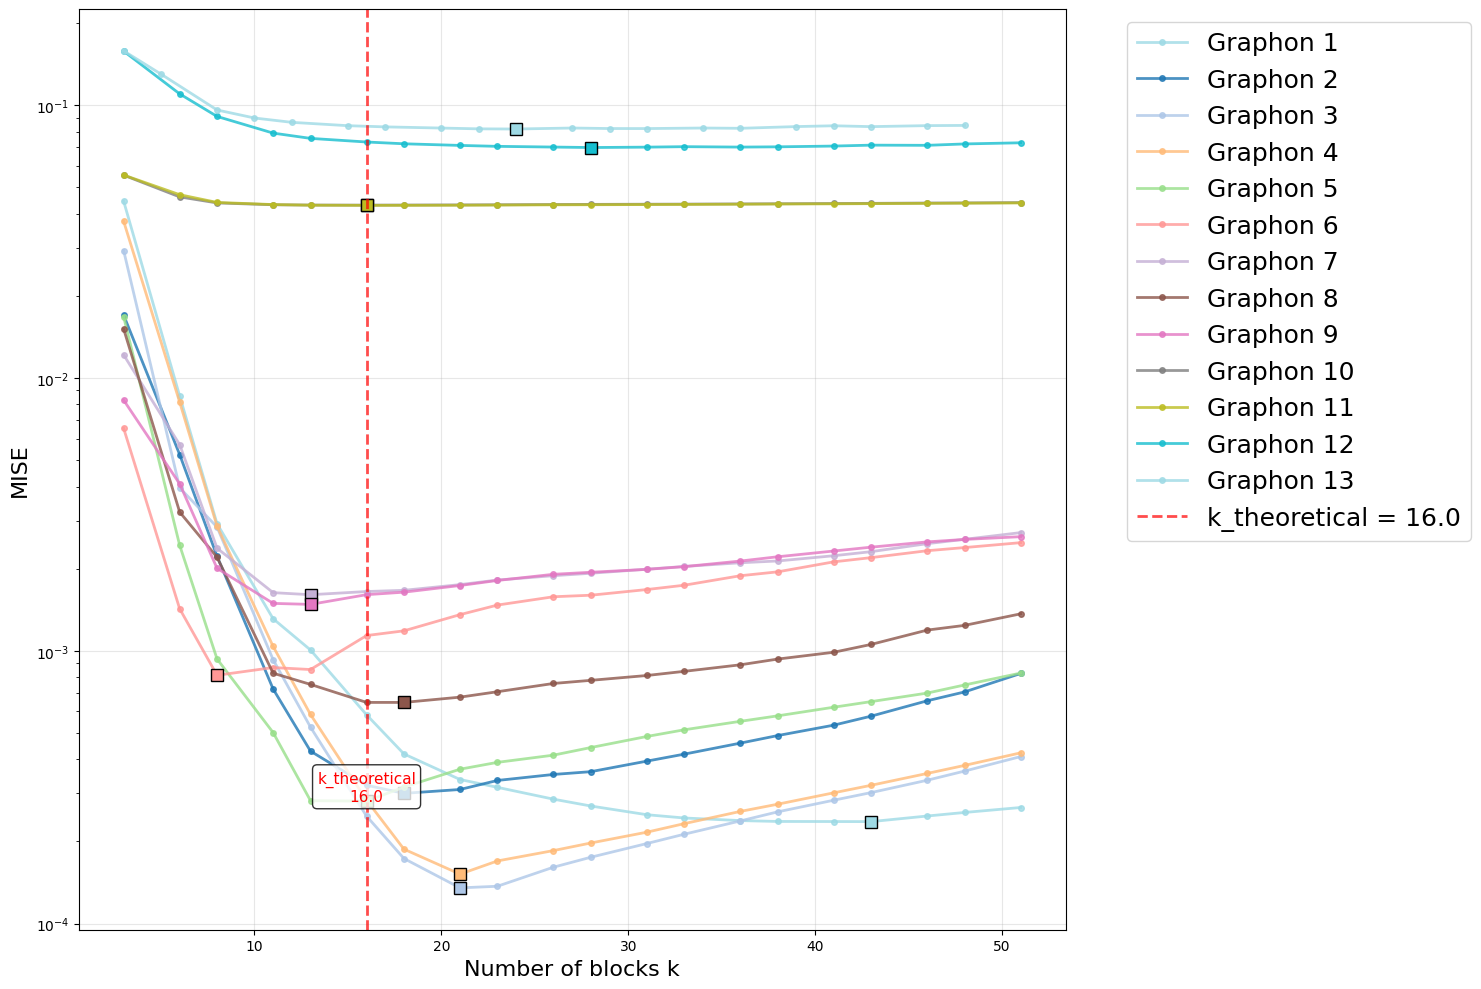


COMPARISON: empirical k_optimal vs k_theoretical (same for all)
Common k_theoretical: 16.0
----------------------------------------------------------------------
Graphon  k_optimal    Difference      Ratio      L2 Error    
----------------------------------------------------------------------
0        43           27.0            2.69       0.0002      
1        18           2.0             1.12       0.0003      
2        21           5.0             1.31       0.0001      
3        21           5.0             1.31       0.0002      
4        16           0.0             1.00       0.0003      
5        8            -8.0            0.50       0.0008      
6        13           -3.0            0.81       0.0016      
7        18           2.0             1.12       0.0006      
8        13           -3.0            0.81       0.0015      
9        16           0.0             1.00       0.0430      
10       16           0.0             1.00       0.0429      
11       28           

In [13]:
all_data, k_theo = load_and_plot_all_graphons(
    metric='l2',
    filename='sens_all_graphons_log.pdf',
    log_scale=True,
    k_theo=int(results_L2_11['theoretical_vals']['k_theoretical'])
)

In [ ]:
S = sum(n**2 for n in vec_n)
N = sum(n for n in vec_n)
M=100

In [ ]:
np.sqrt(np.sqrt(S))

In [ ]:
c = 50  # constante empirique
k_empty_blocks = N / (c * (M + np.log(N)))
k_empty_blocks

In [ ]:
np.log(2)